In [2]:
# ===================================================================
# 1. IMPORT LIBRARY
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
import holidays

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RNN
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import pickle

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


In [3]:
# ===================================================================
# 2. MEMUAT DAN MEMBERSIHKAN DATA
# ===================================================================
from tabulate import tabulate
df = pd.read_csv("ibuprofen.csv")
df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True)
df.sort_values('Tanggal', inplace=True)

df = df.groupby('Tanggal', as_index=False)['Jumlah Terjual'].sum()
full_dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
df = df.set_index('Tanggal').reindex(full_dates).fillna(1).rename_axis('Tanggal').reset_index()

print("\nData setelah dibersihkan dan diisi (5 baris pertama):")

print(tabulate(df.head(), headers='keys', tablefmt='psql', showindex=False))


Data setelah dibersihkan dan diisi (5 baris pertama):
+---------------------+------------------+
| Tanggal             |   Jumlah Terjual |
|---------------------+------------------|
| 2021-01-01 00:00:00 |                1 |
| 2021-01-02 00:00:00 |               50 |
| 2021-01-03 00:00:00 |               65 |
| 2021-01-04 00:00:00 |              161 |
| 2021-01-05 00:00:00 |              170 |
+---------------------+------------------+


In [4]:
# ===================================================================
# 3. FEATURE ENGINEERING (MEMBUAT FITUR BARU)
# ===================================================================
from tabulate import tabulate

df['Bulan'] = df['Tanggal'].dt.month
df['Hari'] = df['Tanggal'].dt.day
df['Hari_Ke'] = df['Tanggal'].dt.dayofyear
df['day_of_week'] = df['Tanggal'].dt.dayofweek
df['is_weekend'] = df['Tanggal'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_start_of_month'] = df['Tanggal'].dt.is_month_start.astype(int)
df['is_end_of_month'] = df['Tanggal'].dt.is_month_end.astype(int)
df['week_of_year'] = df['Tanggal'].dt.isocalendar().week.astype(int)
df['quarter'] = df['Tanggal'].dt.quarter

indonesia_holidays = holidays.Indonesia(years=[df['Tanggal'].min().year, df['Tanggal'].max().year])
holiday_dates = set(indonesia_holidays.keys())
df['is_holiday'] = df['Tanggal'].isin(holiday_dates).astype(int)
df['is_libur'] = ((df['Tanggal'].dt.dayofweek == 6) | (df['is_holiday'] == 1)).astype(int)

df['MA_7_hari'] = df['Jumlah Terjual'].rolling(window=7).mean().fillna(0)

print("\nData setelah Feature Engineering:")
print(tabulate(df.head(), headers='keys', tablefmt='psql', showindex=False))


Data setelah Feature Engineering:
+---------------------+------------------+---------+--------+-----------+---------------+--------------+---------------------+-------------------+----------------+-----------+--------------+------------+-------------+
| Tanggal             |   Jumlah Terjual |   Bulan |   Hari |   Hari_Ke |   day_of_week |   is_weekend |   is_start_of_month |   is_end_of_month |   week_of_year |   quarter |   is_holiday |   is_libur |   MA_7_hari |
|---------------------+------------------+---------+--------+-----------+---------------+--------------+---------------------+-------------------+----------------+-----------+--------------+------------+-------------|
| 2021-01-01 00:00:00 |                1 |       1 |      1 |         1 |             4 |            0 |                   1 |                 0 |             53 |         1 |            1 |          1 |           0 |
| 2021-01-02 00:00:00 |               50 |       1 |      2 |         2 |             5 |    

/tmp/ipython-input-161590230.py:18: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday'] = df['Tanggal'].isin(holiday_dates).astype(int)


In [5]:
# ===================================================================
# 4. MEMISAHKAN FITUR (X) DAN TARGET (y)
# ===================================================================
fitur_input = [
    'Bulan', 'Hari', 'Hari_Ke', 'is_libur', 'is_holiday',
    'day_of_week', 'is_weekend', 'is_start_of_month', 'is_end_of_month',
    'week_of_year', 'quarter', 'MA_7_hari'
]
target = 'Jumlah Terjual'

X_df = df[fitur_input]
y_series = df[target]

print(f"\nJumlah fitur yang digunakan: {len(fitur_input)}")


Jumlah fitur yang digunakan: 12


In [6]:
# ===================================================================
# 5. SCALING DATA
# ===================================================================
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X_df)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y_series.values.reshape(-1, 1))

print("Data X dan y berhasil di-scaling.")

Data X dan y berhasil di-scaling.


In [7]:
# ===================================================================
# 6. MEMBUAT SEKUENS & MEMBAGI DATA TRAIN-TEST
# ===================================================================
def create_sequences(X_data, y_data, time_steps=60):
    Xs, ys = [], []
    for i in range(len(X_data) - time_steps):
        Xs.append(X_data[i:(i + time_steps)])
        ys.append(y_data[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 60
X, y = create_sequences(X_scaled, y_scaled, TIME_STEPS)

# Split data setelah diubah menjadi sekuens
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("\nBENTUK DATA SETELAH DIUBAH MENJADI SEKUENS:")
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_test: {y_test.shape}")


BENTUK DATA SETELAH DIUBAH MENJADI SEKUENS:
Bentuk X_train: (828, 60, 12)
Bentuk y_train: (828, 1)
Bentuk X_test: (207, 60, 12)
Bentuk y_test: (207, 1)


In [8]:
# ===================================================================
# 7. MEMBANGUN ADAPTIVE LSTM (ALSTM)
# ===================================================================

@tf.keras.utils.register_keras_serializable()
class AdaptiveLSTMCell(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        self.units = units
        self.state_size = [units, units, None, 1, units, units]
        self.output_size = units
        super(AdaptiveLSTMCell, self).__init__(**kwargs)

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.state_size[2] = input_dim

        self.W_i = self.add_weight(shape=(input_dim, self.units), name='W_i', initializer='glorot_uniform')
        self.U_i = self.add_weight(shape=(self.units, self.units), name='U_i', initializer='orthogonal')
        self.b_i = self.add_weight(shape=(self.units,), name='b_i', initializer='zeros')
        self.W_f = self.add_weight(shape=(input_dim, self.units), name='W_f', initializer='glorot_uniform')
        self.U_f = self.add_weight(shape=(self.units, self.units), name='U_f', initializer='orthogonal')
        self.b_f = self.add_weight(shape=(self.units,), name='b_f', initializer='zeros')
        self.W_o = self.add_weight(shape=(input_dim, self.units), name='W_o', initializer='glorot_uniform')
        self.U_o = self.add_weight(shape=(self.units, self.units), name='U_o', initializer='orthogonal')
        self.b_o = self.add_weight(shape=(self.units,), name='b_o', initializer='zeros')
        self.W_c = self.add_weight(shape=(input_dim, self.units), name='W_c', initializer='glorot_uniform')
        self.U_c = self.add_weight(shape=(self.units, self.units), name='U_c', initializer='orthogonal')
        self.b_c = self.add_weight(shape=(self.units,), name='b_c', initializer='zeros')

        super(AdaptiveLSTMCell, self).build(input_shape)

    def get_initial_state(self, inputs=None, batch_size=None, dtype=None):
        if inputs is not None:
            batch_size = tf.shape(inputs)[0]
            dtype = inputs.dtype

        # PERBAIKAN KUNCI: Jika dtype masih None, gunakan dtype default dari layer
        if dtype is None:
            dtype = self.dtype

        # Pastikan cell sudah di-build sebelum mengambil input_dim
        if not self.built:
             raise ValueError("The cell has not been built yet. Cannot determine input_dim.")
        input_dim = self.state_size[2]

        # Membuat setiap state awal secara eksplisit
        h_initial = tf.zeros((batch_size, self.units), dtype=dtype)
        c_initial = tf.zeros((batch_size, self.units), dtype=dtype)
        x_prev_initial = tf.zeros((batch_size, input_dim), dtype=dtype)
        d_initial = tf.zeros((batch_size, 1), dtype=dtype)
        h_anchor_initial = tf.zeros((batch_size, self.units), dtype=dtype)
        c_anchor_initial = tf.zeros((batch_size, self.units), dtype=dtype)

        return [h_initial, c_initial, x_prev_initial, d_initial, h_anchor_initial, c_anchor_initial]

    def call(self, inputs, states):
        h_tm1, c_tm1, x_tm1, d_tm1, h_anchor, c_anchor = states

        are_equal = tf.reduce_all(tf.equal(inputs, x_tm1), axis=1, keepdims=True)
        m_t = 1.0 - tf.cast(are_equal, tf.float32)
        d_t = (d_tm1 + 1.0) * (1.0 - m_t) + m_t

        i_t = tf.sigmoid(tf.matmul(inputs, self.W_i) + tf.matmul(h_tm1, self.U_i) + self.b_i)
        f_t = tf.sigmoid(tf.matmul(inputs, self.W_f) + tf.matmul(h_tm1, self.U_f) + self.b_f)
        o_t = tf.sigmoid(tf.matmul(inputs, self.W_o) + tf.matmul(h_tm1, self.U_o) + self.b_o)
        c_in_t = tf.tanh(tf.matmul(inputs, self.W_c) + tf.matmul(h_tm1, self.U_c) + self.b_c)

        c_tilde_t = f_t * c_tm1 + i_t * c_in_t
        h_tilde_t = o_t * tf.tanh(c_tilde_t)

        safe_d_t = tf.where(tf.equal(d_t, 0), 1.0, d_t)
        c_t = m_t * c_tilde_t + (1.0 - m_t) * (1.0 / safe_d_t) * c_anchor
        h_t = m_t * h_tilde_t + (1.0 - m_t) * d_t * h_anchor

        new_c_anchor = m_t * c_t + (1.0 - m_t) * c_anchor
        new_h_anchor = m_t * h_t + (1.0 - m_t) * h_anchor

        new_states = [h_t, c_t, inputs, d_t, new_c_anchor, new_h_anchor]

        return h_t, new_states

In [9]:
# ===================================================================
# 8. MEMBANGUN ARSITEKTUR MODEL DENGAN ALSTM JURNAL
# ===================================================================

print("\nTahap 8: Membangun arsitektur model ALSTM sesuai jurnal...")
model = Sequential([
    RNN(AdaptiveLSTMCell(100), return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    RNN(AdaptiveLSTMCell(50), return_sequences=False),
    Dropout(0.3),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model.summary()

print("\nMemulai pelatihan model...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=150,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)
print("Pelatihan model selesai.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Tahap 8: Membangun arsitektur model ALSTM sesuai jurnal...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (RNN)                       │ (None, 60, 100)        │        45,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,701 (299.61 KB)

 Trainable params: 76,701 (299.61 KB)

 Non-trainable params: 0 (0.00 B)


Memulai pelatihan model...
Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0512 - val_loss: 0.0182
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0332 - val_loss: 0.0131
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0308 - val_loss: 0.0108
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0297 - val_loss: 0.0120
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0273 - val_loss: 0.0102
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0293 - val_loss: 0.0100
Epoch 7/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0289 - val_loss: 0.0105
Epoch 8/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0271 - val_loss: 0.0105
Epoch 9/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0269 - val_loss: 0.0158
Epoch 10/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0265 - val_loss: 0.0111
Epoch 11/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0246 - val_loss: 0.0110
Epoch 12/150
26/26 ━

In [10]:
# ===================================================================
# 8. MENYIMPAN MODEL DAN SCALER
# ===================================================================
model.save('model_ibuprofen_alstm_final.h5')
pickle.dump(scaler_X, open('scaler_X.pkl', 'wb'))
pickle.dump(scaler_y, open('scaler_y.pkl', 'wb'))

print("\nTahap 8: Model dan scaler berhasil disimpan!")
print("Anda sekarang siap untuk melanjutkan ke pembuatan aplikasi web.")


Tahap 8: Model dan scaler berhasil disimpan!
Anda sekarang siap untuk melanjutkan ke pembuatan aplikasi web.


In [11]:
# ===================================================================
# 9.DENORMALISASI
# ===================================================================

# Lakukan prediksi pada data uji (X_test)
y_pred_scaled = model.predict(X_test)

# Dapatkan tanggal yang sesuai dengan data X_test untuk pengecekan hari libur
train_size_index = len(X_train) + TIME_STEPS
test_dates_for_check = df['Tanggal'].iloc[train_size_index:].reset_index(drop=True)

# Dapatkan nilai '1' yang sudah di-scale untuk menimpa prediksi
one_scaled = scaler_y.transform(np.array([[1]]))

# Loop melalui setiap prediksi dan terapkan aturan 'libur=1'
for i in range(len(y_pred_scaled)):
    current_date = test_dates_for_check[i]
    # Cek apakah hari Minggu (6) atau tanggal merah
    if current_date.weekday() == 6 or current_date.date() in holiday_dates:
        y_pred_scaled[i] = one_scaled[0]

# Setelah aturan diterapkan, lakukan denormalisasi
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


In [12]:
# ===================================================================
# 10. EVALUASI
# ===================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Hitung semua metrik evaluasi
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("\n--- Hasil Evaluasi Model ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")


--- Hasil Evaluasi Model ---
Mean Absolute Error (MAE): 12.07
Root Mean Squared Error (RMSE): 16.16
R-squared (R2 Score): 0.15


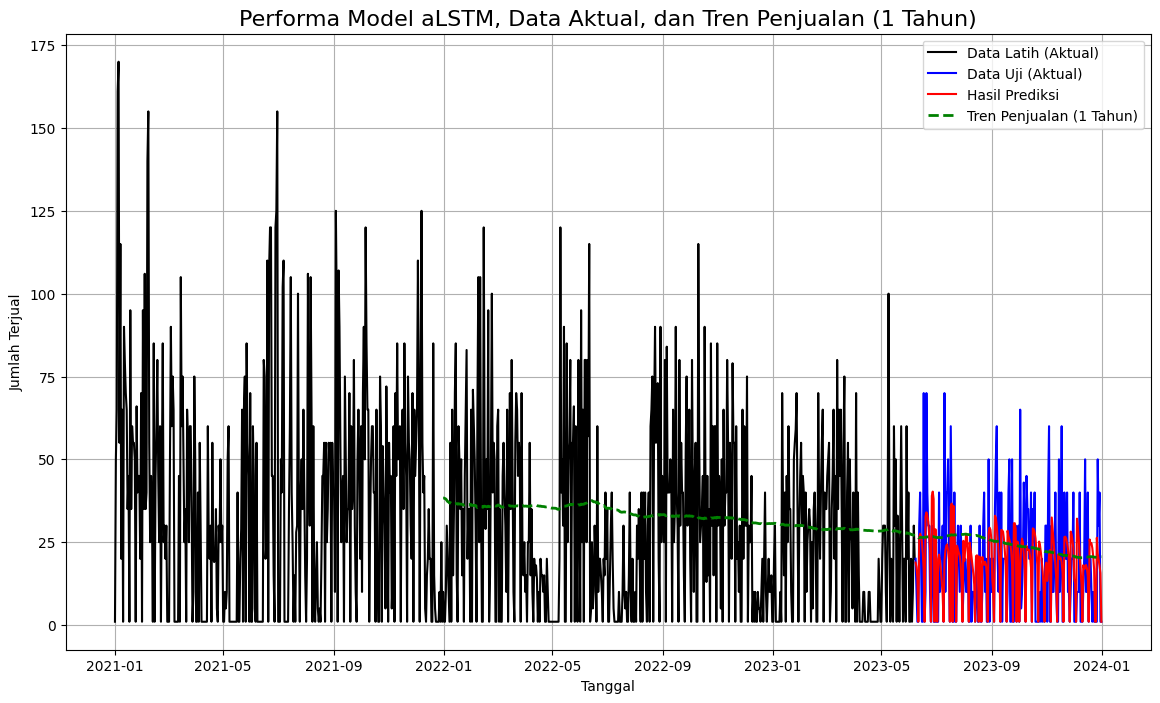

In [13]:
# ===================================================================
# 11. VISUALISASI
# ===================================================================
import matplotlib.pyplot as plt

# --- PERSIAPAN DATA ---

# Menghitung trend menggunakan rolling average 365 hari
df['Trend_1_Tahun'] = df['Jumlah Terjual'].rolling(window=365).mean()

# PERUBAHAN DI SINI: Buang nilai NaN dari data tren agar grafik tidak dimulai dari awal
trend_plot_data = df.dropna(subset=['Trend_1_Tahun'])

# Memisahkan data untuk plotting
train_plot_df = df.iloc[:train_size_index]
test_plot_df = df.iloc[train_size_index:]

# --- PLOTTING ---
plt.figure(figsize=(14, 8))

# Plot data aktual (latih dan uji)
plt.plot(train_plot_df['Tanggal'], train_plot_df['Jumlah Terjual'], color='black', label='Data Latih (Aktual)')
plt.plot(test_plot_df['Tanggal'], y_test_actual, color='blue', label='Data Uji (Aktual)')

# Plot hasil prediksi
plt.plot(test_plot_df['Tanggal'], y_pred, color='red', label='Hasil Prediksi')

# Plot garis tren
plt.plot(trend_plot_data['Tanggal'], trend_plot_data['Trend_1_Tahun'], color='green', linestyle='--', linewidth=2, label='Tren Penjualan (1 Tahun)')

# Mengatur judul dan label
plt.title('Performa Model aLSTM, Data Aktual, dan Tren Penjualan (1 Tahun)', fontsize=16)
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Terjual')
plt.legend()
plt.grid(True)
plt.show()


--- Hasil Prediksi Penjualan 30 Hari ke Depan ---
      Tanggal  Prediksi Jumlah Terjual
0  2024-01-01                       13
1  2024-01-02                       16
2  2024-01-03                       20
3  2024-01-04                       20
4  2024-01-05                       16
5  2024-01-06                       12
6  2024-01-07                        1
7  2024-01-08                       31
8  2024-01-09                       37
9  2024-01-10                       37
10 2024-01-11                       34
11 2024-01-12                       29
12 2024-01-13                       21
13 2024-01-14                        1
14 2024-01-15                       38
15 2024-01-16                       43
16 2024-01-17                       42
17 2024-01-18                       38
18 2024-01-19                       32
19 2024-01-20                       24
20 2024-01-21                        1
21 2024-01-22                       39
22 2024-01-23                       44
23 2024-01-24

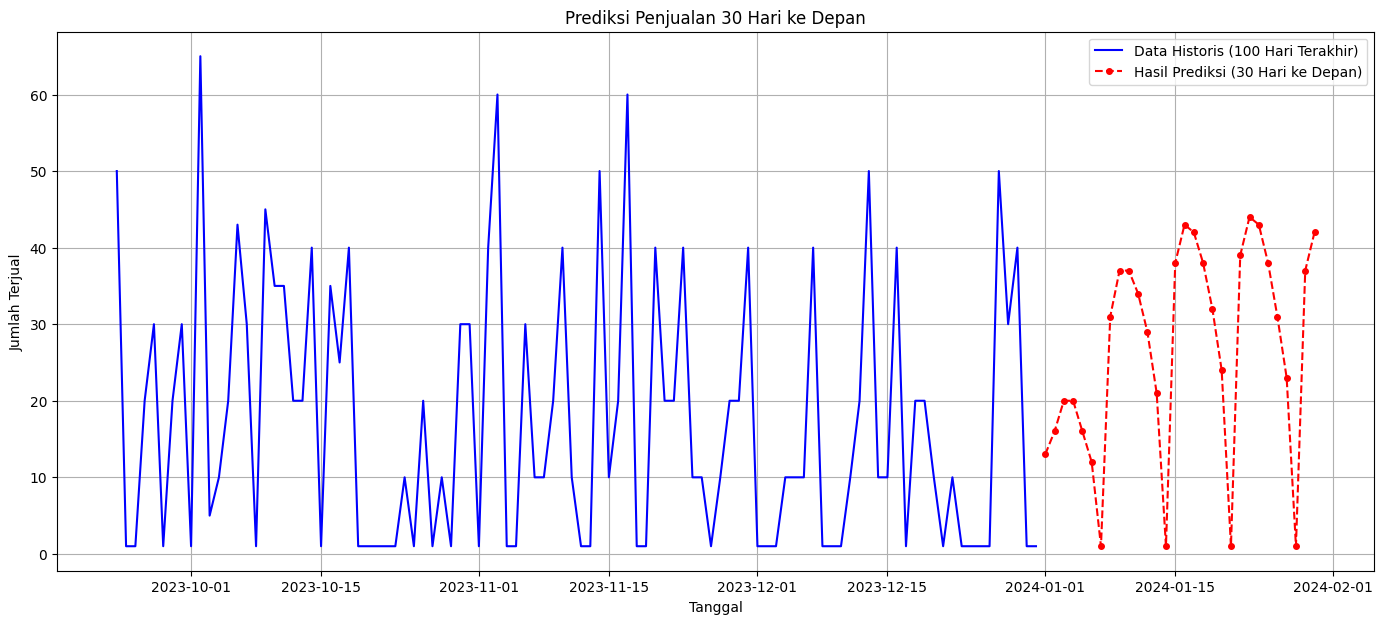

In [14]:
# ===================================================================
# 12. MEMBUAT PREDIKSI UNTUK 30 HARI KE DEPAN
# ===================================================================

# 1. Siapkan data input awal dari 60 hari terakhir di dataset Anda
last_sequence_df = df.tail(TIME_STEPS) # TIME_STEPS = 60
current_sequence_scaled = scaler_X.transform(last_sequence_df[fitur_input])

# 2. Inisialisasi variabel untuk loop prediksi
future_predictions_scaled = []
current_sequence = current_sequence_scaled.reshape(1, TIME_STEPS, len(fitur_input))
last_date = df['Tanggal'].iloc[-1]
last_sales = list(df['Jumlah Terjual'].tail(6)) # Untuk menghitung MA_7_hari

# Dapatkan nilai '1' yang sudah di-scale untuk aturan hari libur
one_scaled = scaler_y.transform(np.array([[1]]))

# 3. Lakukan loop prediksi sebanyak 30 kali (untuk 30 hari)
for i in range(30):
    # Prediksi 1 hari ke depan
    pred_scaled = model.predict(current_sequence, verbose=0)

    # Tentukan tanggal untuk hari yang diprediksi
    next_date = last_date + timedelta(days=i + 1)

    # Cek apakah hari berikutnya adalah hari libur (Minggu atau tanggal merah)
    is_next_day_libur = (next_date.weekday() == 6) or (next_date.date() in holiday_dates)

    # Terapkan aturan: jika hari libur, paksa prediksi menjadi 1
    if is_next_day_libur:
        pred_scaled[0, 0] = one_scaled[0, 0]

    future_predictions_scaled.append(pred_scaled[0, 0])

    # Inverse transform prediksi untuk digunakan di fitur MA berikutnya
    pred_actual = scaler_y.inverse_transform(pred_scaled)[0, 0]
    last_sales.append(pred_actual)

    # Buat fitur-fitur baru untuk hari berikutnya
    new_features = {
        'Bulan': next_date.month, 'Hari': next_date.day, 'Hari_Ke': next_date.dayofyear,
        'is_libur': 1 if is_next_day_libur else 0,
        'is_holiday': 1 if next_date.date() in holiday_dates else 0,
        'day_of_week': next_date.dayofweek, 'is_weekend': 1 if next_date.dayofweek >= 5 else 0,
        'is_start_of_month': 1 if next_date.is_month_start else 0,
        'is_end_of_month': 1 if next_date.is_month_end else 0,
        'week_of_year': next_date.isocalendar()[1], 'quarter': next_date.quarter,
        'MA_7_hari': np.mean(last_sales[-7:])
    }

    # Scale fitur baru dan update sequence untuk iterasi berikutnya
    new_features_df = pd.DataFrame([new_features], columns=fitur_input)
    new_features_scaled = scaler_X.transform(new_features_df)
    current_sequence = np.append(current_sequence[:, 1:, :], new_features_scaled.reshape(1, 1, len(fitur_input)), axis=1)

# 4. Denormalisasi semua hasil prediksi
predictions = scaler_y.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))
predictions = np.round(predictions.flatten()).astype(int)

# 5. Tampilkan hasil dalam bentuk tabel
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30, freq='D')
forecast_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi Jumlah Terjual': predictions})

print("\n--- Hasil Prediksi Penjualan 30 Hari ke Depan ---")
print(forecast_df)


# 6. Visualisasi Hasil Prediksi
plt.figure(figsize=(17, 7))
# Plot data historis 100 hari terakhir untuk konteks
plt.plot(df['Tanggal'].tail(100), df['Jumlah Terjual'].tail(100), color='blue', label='Data Historis (100 Hari Terakhir)')
# Plot hasil prediksi
plt.plot(future_dates, predictions, color='red', linestyle='--', marker='o', markersize=4, label='Hasil Prediksi (30 Hari ke Depan)')
plt.title('Prediksi Penjualan 30 Hari ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Terjual')
plt.legend()
plt.grid(True)
plt.show()